# Домашнее задание к занятию «Классификация: Логистическая регрессия и SVM»

Выполнил: Ярослав Золотухин

<b>Задача: решить задачу классификации физических лиц по уровню дохода </b>

## ШАГ 0. Устанавливаем необходимые библиотеки и импортируем их

In [1]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install sklearn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip in

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Шаг 1. Загружаем данные в рабочую среду

In [3]:
data = pd.read_csv( 'adult.csv' )
data.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


Явные пропуски отсутствуют, но можно заметить что в части данных указан неявный пропуск символом "?". Пройдемся по всем столбцам и удалим лишние строки

In [5]:
for col in data.columns:
    data = data.drop(data[data[col] == '?'].index)

In [6]:
data.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K


Для проверки посмотрим уникальные значения столбца <b>native-country</b>

In [7]:
data['native-country'].unique()

array(['United-States', 'Peru', 'Guatemala', 'Mexico',
       'Dominican-Republic', 'Ireland', 'Germany', 'Philippines',
       'Thailand', 'Haiti', 'El-Salvador', 'Puerto-Rico', 'Vietnam',
       'South', 'Columbia', 'Japan', 'India', 'Cambodia', 'Poland',
       'Laos', 'England', 'Cuba', 'Taiwan', 'Italy', 'Canada', 'Portugal',
       'China', 'Nicaragua', 'Honduras', 'Iran', 'Scotland', 'Jamaica',
       'Ecuador', 'Yugoslavia', 'Hungary', 'Hong', 'Greece',
       'Trinadad&Tobago', 'Outlying-US(Guam-USVI-etc)', 'France',
       'Holand-Netherlands'], dtype=object)

## Шаг 2. Визуализируем данные

Отобразим точечную диаграмму и рассмотрим уровень дохода в завимости от уровня образования с разбивкой по категориям. 
Так как уровень дохода у нас имеет только 2 значения, то отобразим их на графике различными цветами.

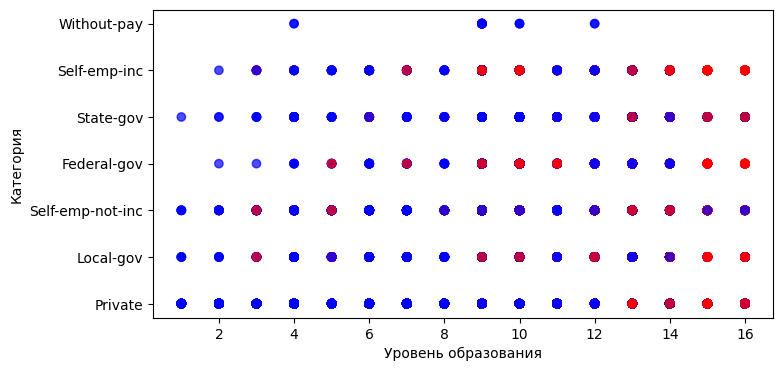

In [8]:
# Сопоставляем значениям income конкретные цвета
point_colors = data['income'].map({'<=50K': 'blue', '>50K': 'red'})

plt.figure(figsize=(8, 4))
plt.scatter(data['educational-num'], data['workclass'], c=point_colors, alpha=0.7)

plt.ylabel('Категория')
plt.xlabel('Уровень образования')
plt.show()

На данной диаграмме видно, что с ростом образования количество людей с высоким доходом превалирует для всех категорий.

Отобразим столбчатую диаграмму в разрезе пола.

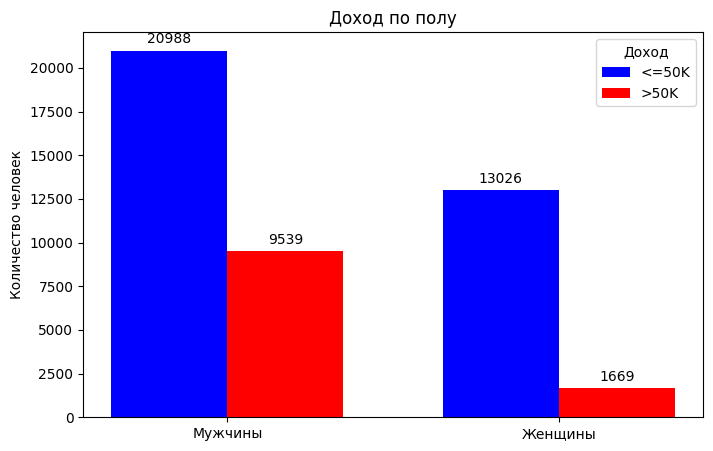

In [9]:
males = data[data['gender'] == 'Male']['income'].value_counts()
females = data[data['gender'] == 'Female']['income'].value_counts()

low_income = [males.get('<=50K', 0), females.get('<=50K', 0)]
high_income = [males.get('>50K', 0), females.get('>50K', 0)]

labels = ['Мужчины', 'Женщины']

# настройка координат для раздельных столбцов
x = np.arange(len(labels))  # Возвращает массив [0, 1]
width = 0.35                # Задаем ширину столбцов

plt.figure(figsize=(8, 5))

# Рисуем столбцы, сдвигая их от центра (x)
# Первый сдвигаем влево на половину ширины
bar1 = plt.bar(x - width/2, low_income, width, color='blue', label='<=50K')
plt.bar_label(bar1, padding=3)

# Второй сдвигаем вправо на половину ширины
bar2 = plt.bar(x + width/2, high_income, width, color='red', label='>50K')
plt.bar_label(bar2, padding=3)

# 4. Оформление графика
plt.ylabel('Количество человек')
plt.title('Доход по полу')
plt.xticks(x, labels) # Устанавливаем текстовые метки ('Мужчины', 'Женщины') по центру
plt.legend(title='Доход')

plt.show()

Исходя из представленных данных можем сделать вывод о том, что количество женщин с высоким доходом меньше как в абсолютном, так и относительном выражении.

## Шаг 3. Преобразование категориальных признаков

In [10]:
from sklearn.linear_model import LogisticRegression

In [42]:
# попробуем выбрать отображаемые нами выше признаки
selectedColumns = data[ [ 'educational-num', 'native-country', 'income' ] ]

# столбец native-country является категориальной переменной
X = pd.get_dummies( selectedColumns, columns = [ 'native-country' ] )

# столбец income является целевой переменной, удаляем его из X
del X['income']
X.head()

,educational-num,native-country_Cambodia,native-country_Canada,native-country_China,native-country_Columbia,native-country_Cuba,native-country_Dominican-Republic,native-country_Ecuador,native-country_El-Salvador,native-country_England,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,7,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,9,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,12,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,10,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
5,6,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [43]:
# целевая переменная (столбец income) снова является категориальной
# переведем значения столбца в числа, оставив один столбец

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [44]:
le.fit( data['income'] )

LabelEncoder()

In [45]:
# записываем в переменную y преобразованный столбец income

y = pd.Series( data = le.transform( data['income'] ) )
y.head()

0    0
1    0
2    1
3    1
4    0
dtype: int64

## Шаг 4. Обучение

 Поделим данные на обучающую выборку и тестовую. На тестовую выборку оставляем 20%.

In [46]:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Обучим модель логистической регрессии

In [47]:
model_logReg = LogisticRegression()

In [48]:
# обучаем модель

model_logReg.fit( X_train, y_train )
predictions = model_logReg.predict( X_test )

In [49]:
predictions

array([0, 0, 0, ..., 0, 0, 0])

In [50]:
model_logReg.predict_proba(X_test)

array([[0.93996001, 0.06003999],
       [0.84250203, 0.15749797],
       [0.72333293, 0.27666707],
       ...,
       [0.84250203, 0.15749797],
       [0.84250203, 0.15749797],
       [0.94490856, 0.05509144]])

Получаем наш скор (точность предсказания) на обучающей и тестовой выборках.

In [51]:
model_logReg.score(X_train, y_train) 

0.7723415429692899

In [52]:
model_logReg.score(X_test,y_test)

0.7756771697070205

### Обучим модель опорных векторов. SVM.

In [53]:
from sklearn.svm import SVC

model_svc = SVC()
model_svc.fit(X_train, y_train)

SVC()

In [54]:
model_svc.score(X_train, y_train) 

0.7649335212980624

In [55]:
model_svc.score(X_test, y_test)

0.7734660033167496

In [56]:
model2 = SVC(kernel='poly', degree=7)
model2.fit(X_train, y_train)

SVC(degree=7, kernel='poly')

In [57]:
model2.score(X_train, y_train)

0.765652209967659

# Выводы по проделанной работе

В ходе данного домашнего задания был выполнен анализ файла adult.csv для решения задачи бинарной класификации, удалены из выборки неявные пропуски, отображены графики по части признаков. 

Для построения модели были выбраны 2 признака: 

1. educational-num (числовой уровень образования)
2. native-country (страна происхождения, категориальный) 

- native-country преобразован методом one-hot encoding (функция pd.get_dummies)
- Целевая переменная income (категории <=50K и >50K) закодирована в 0 и 1 с помощью LabelEncoder.
- Выборка разбита по принципу 80/20

После подготовки данных рассматривались 2 различные модели на идентичных данных, где

| Модель | Точность на обучении | Точность на тесте |
|--------|----------------------|-------------------|
| Логистическая регрессия | 0.7723 | 0.7757 |
| SVM | 0.7649 | 0.7735 |


Обе модели дают близкие результаты, что говорит об отсутствии сильного переобучения (разница train/test мала). Дополнительный эксперимент с полиномиальным SVM (degree=7) не улучшил результат.

Модели частично справились со своей задачей, но качество можно считать средним.
Точность около 77,6% – это лучше случайного угадывания (баланс классов примерно 75% / 25% в пользу <=50K).
Однако для практического применения такой показатель часто признаётся недостаточным. Ошибки в 22–23% слишком велики.

<b>Для улучшения качества можно увеличить количество признаков, используемых в модели, либо использовать другие модели.</b>